In [119]:
import numpy as np
import matplotlib.pyplot as plt

In [120]:
# Set random seed for reproducability
np.random.seed(42)

In [121]:
# Training data: XOR
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

In [122]:
print("XOR dataset")
print("="*30)

for i in range(len(X)):
    print(f"Input: {X[i]} --> Output: {y[i][0]}")

XOR dataset
Input: [0 0] --> Output: 0
Input: [0 1] --> Output: 1
Input: [1 0] --> Output: 1
Input: [1 1] --> Output: 0


### Plot the XOR data

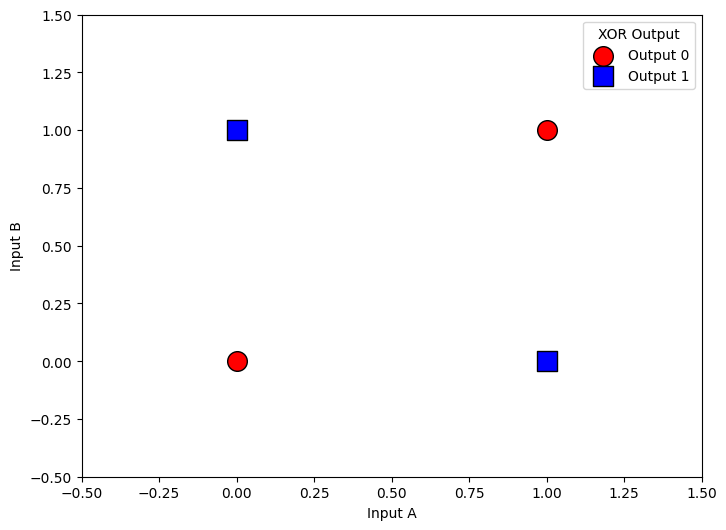

In [123]:
plt.figure(figsize=(8, 6))

# Separate points by class
X0 = X[y[:, 0] == 0]
X1 = X[y[:, 0] == 1]

plt.scatter(X0[:, 0], X0[:, 1], color='red', label='Output 0', marker='o', s=200, edgecolors='black')
plt.scatter(X1[:, 0], X1[:, 1], color='blue', label='Output 1', marker='s', s=200, edgecolors='black')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.xlabel("Input A")
plt.ylabel("Input B")
plt.legend(title='XOR Output')
plt.show()


## Building the Neural Network

### Our Architecture

<pre>
Input layer (2 neurons) -> Hidden layer (4 neurons) -> Output layer (1 neuron)
</pre>

- <b>Input:</b> 2 values (The two XOR inputs)
- <b>Hidden:</b> 4 neurons with sigmoid
- <b>Output:</b> 1 neuron with sigmoid activation function (gives us 0-1 probability)

#### Why Sigmoid?
For this educational example we will use sigmoid because:
- Output is naturally between 0 and 1 (matches our target)
- Maths is clean and easy to follow
- Historically important

In practice we will use ReLU for hidden layers, but sigmoid helps us in uunderstanding what's happening

In [124]:
# Network architecture
INPUT_SIZE = 2
HIDDEN_SIZE = 4
OUTPUT_SIZE = 1

## Part 1: Initialise weights and Biases

In [125]:
# initialise weights randomly
# using small values centered around 0

In [126]:
# Layer 1 weights
# Matrix of the size (input_size) x (hidden layer size)
hidden_layer_weights = np.random.randn(INPUT_SIZE, HIDDEN_SIZE) * 0.5
bias_hidden = np.zeros((1, HIDDEN_SIZE))

In [127]:
hidden_layer_weights

array([[ 0.24835708, -0.06913215,  0.32384427,  0.76151493],
       [-0.11707669, -0.11706848,  0.78960641,  0.38371736]])

In [128]:
bias_hidden

array([[0., 0., 0., 0.]])

In [129]:
# Output layer weights
# matrix of the size (hidden layer size) x (output size)
output_layer_weights = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * 0.5
bias_output = np.zeros((1, OUTPUT_SIZE))

In [130]:
print("Network initialised with random weights")
print(f"  Hidden layer weight shape: {hidden_layer_weights.shape}")
print(f"  Output layer weight shape: {output_layer_weights.shape}")
print("Total parameter: ", hidden_layer_weights.size + bias_hidden.size + output_layer_weights.size + bias_output.size)

Network initialised with random weights
  Hidden layer weight shape: (2, 4)
  Output layer weight shape: (4, 1)
Total parameter:  17


### The Activation function: Sigmoid

- Sigmoid reduces any number in the range 0 to 1
- Large positive nos. -> close to 1
- Large negative nos. -> close to 0
- zero -> exactly 0.5

We also need its derivative for backpropagation

In [131]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s =sigmoid(x)

    return s * (1 - s)

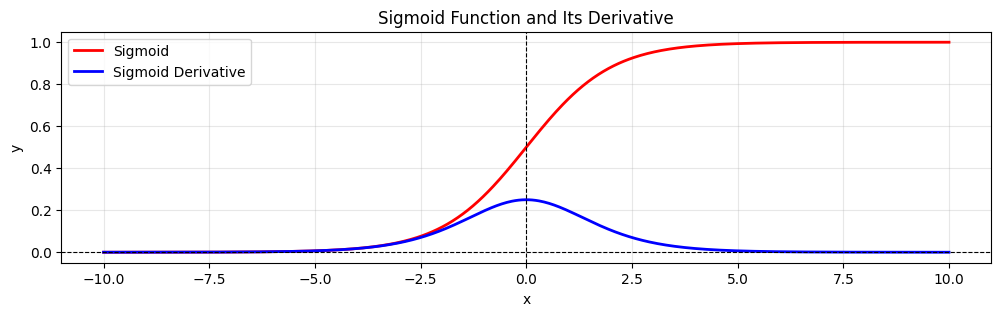

In [132]:
# Visualize sigmoid
x_vals = np.linspace(-10, 10, 500)

plt.figure(figsize=(12, 3))
plt.plot(x_vals, sigmoid(x_vals), label="Sigmoid", linewidth=2, c='red')
plt.plot(x_vals, sigmoid_derivative(x_vals), label="Sigmoid Derivative", linewidth=2, c='blue')

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Sigmoid Function and Its Derivative")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [133]:
print("Notice: The maximum derivative is only 0.25!")
print("   This is the vanishing gradient problem")
print("   10 layers: 0.25^10 = ", 0.25**10)

Notice: The maximum derivative is only 0.25!
   This is the vanishing gradient problem
   10 layers: 0.25^10 =  9.5367431640625e-07


## Part 2: Forward pass
Forward pass is how the data moves through the network
- <b>Input -> Hidden: </b> Multiply inputs by weights, sum them up and add biases -> apply activation func. ```(Sigmoid)```
- <b> Hidden -> Output: </b> Multiply the outputs of hidden layer by weight and add bias -> apply activation function

In [134]:
def forward(x):
    # Step 1: Input to hidden layer
    # Matrix multiplication between input data and hidden layer weights
    z_hidden = np.dot(x, hidden_layer_weights) + bias_hidden

    # Apply activation to hidden layer
    a_hidden = sigmoid(z_hidden)

    # Step 2: Hidden layer to output
    # Use the activated hidden outputs, not the raw pre-activation values
    z_output = np.dot(a_hidden, output_layer_weights) + bias_output

    # Final activation
    a_output = sigmoid(z_output)

    # Return everything
    return z_hidden, a_hidden, z_output, a_output


### Understanding Matrix Shapes: Input → Hidden Layer

### The Shapes
- **X (Input data):** (4, 2) → 4 samples, 2 features each
- **hidden_layer_weights:** (2, 4) → 2 inputs connect to 4 hidden neurons
- **Result z_hidden:** (4, 4) → 4 samples, 4 neuron outputs

#### What the (4, 4) Result Matrix Represents

```
                    H1      H2      H3      H4
                   ────    ────    ────    ────
Sample 1 [0,0]:  | out  |  out  |  out  |  out |
Sample 2 [0,1]:  | out  |  out  |  out  |  out |
Sample 3 [1,0]:  | out  |  out  |  out  |  out |
Sample 4 [1,1]:  | out  |  out  |  out  |  out |
```

**Each column = one hidden neuron's output across all 4 samples**
**Each row = one sample's output across all 4 hidden neurons**

#### Breaking it Down

| Dimension | Meaning |
|-----------|---------|
| 4 rows | One per training sample (we process all 4 XOR samples at once) |
| 4 columns | One per hidden neuron (each produces 1 output per sample) |
| **Total: 16 values** | 4 samples × 4 neurons = 16 scalar outputs |

#### Concrete Example
```
z_hidden[0, :] = outputs of all 4 hidden neurons for sample [0,0]
z_hidden[1, :] = outputs of all 4 hidden neurons for sample [0,1]
z_hidden[2, :] = outputs of all 4 hidden neurons for sample [1,0]
z_hidden[3, :] = outputs of all 4 hidden neurons for sample [1,1]
```

Each hidden neuron receives a weighted combination of the 2 inputs, producing 1 number per sample.

In [135]:
# Test one fwd pass with untrained network
z_h, a_h, z_o, predictions = forward(X)

In [136]:
print("Forward pass with untrained network")
print("="*50)

for i in range(len(X)):
    print(f"Input: {X[i]} -> Prediction: {predictions[i][0]:.4f} | Target: {y[i][0]}")

print("="*50)
print("Predictions are garbage, model hasn't learned anything yet")

Forward pass with untrained network
Input: [0 0] -> Prediction: 0.4467 | Target: 0
Input: [0 1] -> Prediction: 0.4303 | Target: 1
Input: [1 0] -> Prediction: 0.4270 | Target: 1
Input: [1 1] -> Prediction: 0.4126 | Target: 0
Predictions are garbage, model hasn't learned anything yet


### Loss function

Loss meaures how wrong out predictions are. ```The lower, the better```


### Mean Squared Error

<b>MSE = mean(actual - predicted)<sup>2</sup></b>

<b>Why square?</b>
- All errors are positive so they don't cancel out each other
- Big errors are penalized more

In [137]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

### Calculate Initial loss

In [138]:
# Calculate initial loss
initial_loss = mse(y, predictions)
print("Initial loss (Untrained network): ", initial_loss)

Initial loss (Untrained network):  0.2556753002334093


## Part 3: Backpropagation

This is where the magic happens
Backpropagation answers: <b>Which weights caused the error and how much?</b>

### The chain of blame
- Calculate loss at output.
- Figure out how much each output layer weight contributed.
- Propagate error back to hidden layer.
- Figure out how much each hidden layer weight contributed.
- Adjust all weights proportionally

The maths uses chain rule from calculus but the intuition is <b>blame propagates backward</b>

In [139]:
def backward(X, y, z_hidden, a_hidden, z_output, a_output, learning_rate):
    """
    Backpropagation: Compute gradients and adjust weights
    """
    global hidden_layer_weights, output_layer_weights, bias_hidden, bias_output

    n = X.shape[0]  # no. of training examples

    #============= OUTPUT LAYER ====================================

    # Error at output: Difference between prediction and target
    output_error = a_output - y  # Shape: (4 x 1)

    # Gradient of loss w.r.t z_output (before activation)
    output_delta = output_error * sigmoid_derivative(z_output)  # Shape: (4 x 1)

    # Gradients for output layer parameters
    grad_output_layer_weights = np.dot(a_hidden.T, output_delta) / n
    grad_bias_output = np.mean(output_delta, axis=0, keepdims=True)

    # =========== HIDDEN LAYER =======================================

    # Propagate error back to hidden layer
    hidden_error = np.dot(output_delta, output_layer_weights.T)

    # Gradient of loss w.r.t. z_hidden
    hidden_delta = hidden_error * sigmoid_derivative(z_hidden)

    # Gradients for hidden layer parameters
    grad_hidden_layer_weights = np.dot(X.T, hidden_delta) / n
    grad_bias_hidden = np.mean(hidden_delta, axis=0, keepdims=True)

    # ========== UPDATE WEIGHTS ==========
    # Move weights in the opposite direction of the gradient
    output_layer_weights -= learning_rate * grad_output_layer_weights
    bias_output -= learning_rate * grad_bias_output
    hidden_layer_weights -= learning_rate * grad_hidden_layer_weights
    bias_hidden -= learning_rate * grad_bias_hidden

print("Backpropagation function defined")
print("This is the 'learning' part -> Adjusting weights to reduce error")

Backpropagation function defined
This is the 'learning' part -> Adjusting weights to reduce error


## Part 4: The Training loop

Now we put it all together:
- For each iteration:
    - Forward pass -> get predictions
    - Calculate loss -> How wrong are we?
    - Backward pass -> Compute gradients, update weights

Lets train for 10k iterations and see the loss decrease

In [140]:
# Reset weights
np.random.seed(42)
hidden_layer_weights = np.random.randn(INPUT_SIZE, HIDDEN_SIZE) * 0.5
bias_hidden = np.zeros(shape=(1, HIDDEN_SIZE))

output_layer_weights = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * 0.5
bias_output = np.zeros(shape=(1, OUTPUT_SIZE))

In [141]:
# Hyperparameters
learning_rate = 2.0
epochs = 10000

In [142]:
# Track loss overtime
loss_history = []

In [143]:
print("Training started")
print("="*50)

for i in range(epochs):
    # Forward pass
    z_h, a_h, z_o, predictions = forward(X)

    # Calculate loss
    loss = mse(y, predictions)
    loss_history.append(loss)

    # Backward pass (updates weights internally)
    backward(X, y, z_h, a_h, z_o, predictions, learning_rate)

    # Print progress
    if i % 500 == 0:
        print(f"Iteration: {i:5d} Loss: {loss:.6f}")



Training started
Iteration:     0 Loss: 0.255675
Iteration:   500 Loss: 0.249661
Iteration:  1000 Loss: 0.203313
Iteration:  1500 Loss: 0.022918
Iteration:  2000 Loss: 0.005210
Iteration:  2500 Loss: 0.002664
Iteration:  3000 Loss: 0.001743
Iteration:  3500 Loss: 0.001280
Iteration:  4000 Loss: 0.001005
Iteration:  4500 Loss: 0.000824
Iteration:  5000 Loss: 0.000696
Iteration:  5500 Loss: 0.000602
Iteration:  6000 Loss: 0.000529
Iteration:  6500 Loss: 0.000472
Iteration:  7000 Loss: 0.000425
Iteration:  7500 Loss: 0.000387
Iteration:  8000 Loss: 0.000355
Iteration:  8500 Loss: 0.000327
Iteration:  9000 Loss: 0.000304
Iteration:  9500 Loss: 0.000283


Final results
Initial loss: 0.255675
Final loss:   0.000265

Input: [0 0] | Target: 0 | Prediction: 0.0187 | Predicted class: 0
Input: [0 1] | Target: 1 | Prediction: 0.9845 | Predicted class: 1
Input: [1 0] | Target: 1 | Prediction: 0.9844 | Predicted class: 1
Input: [1 1] | Target: 0 | Prediction: 0.0151 | Predicted class: 0


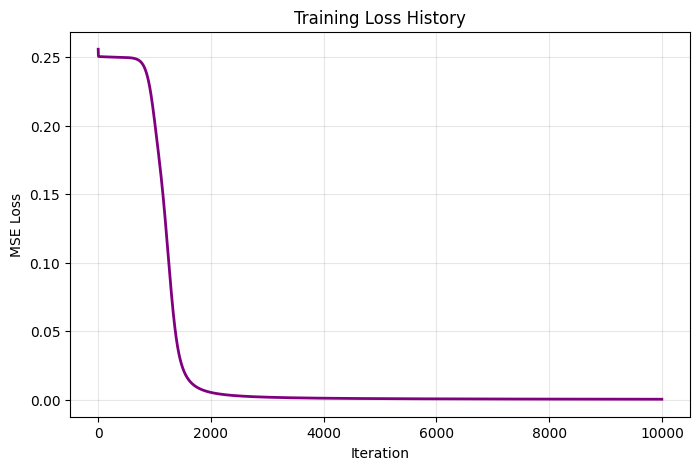

In [144]:
# Final results after training
_, _, _, final_predictions = forward(X)
final_loss = mse(y, final_predictions)
predicted_classes = (final_predictions > 0.5).astype(int)

print("Final results")
print("=" * 50)
print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss:   {final_loss:.6f}")
print()

for i in range(len(X)):
    print(
        f"Input: {X[i]} | Target: {y[i][0]} | "
        f"Prediction: {final_predictions[i][0]:.4f} | "
        f"Predicted class: {predicted_classes[i][0]}"
    )

plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='purple', linewidth=2)
plt.title("Training Loss History")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.show()